In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
from datetime import datetime
from zoneinfo import ZoneInfo
import torch
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from tqdm import tqdm
from datasets import Dataset
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import subprocess
import time
from nrclex import NRCLex
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer



[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/katechamberlain/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
data_dir = os.path.join('..', 'data', 'processed', 'US')

train_path = os.path.join(data_dir, 'multimodal_train.tsv')
val_path = os.path.join(data_dir, 'multimodal_validate.tsv')
test_path = os.path.join(data_dir, 'multimodal_test_public.tsv')

train_df = pd.read_csv(train_path, sep='\t')
val_df = pd.read_csv(val_path, sep='\t')
test_df = pd.read_csv(test_path, sep='\t')

In [9]:
train_df.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


### 1. Virality target construction 

Was going to use VAI (Chauhan et al., 2025) but they rely on post **age**, which I don't have as I'm using static snapshots. Instead, employ the methodology of **Barnes et al. (2020)** from Dank or Not meme paper.

They use feature extraction and then run both random forest and gradient boost models on the fulll feature set. They also use a dataset that's extracted from pushift - same as Fakeddit and my UK dataset so it's a good match.

Highly cited paper (72 citations) so an authoritative source in the research space

Construct virality labels
- Populatiry metric based on upvotes and number of comments - community engagement 
- Chauhan et al. 2025 use upvotes + num_comments in their VAI equation, then divide by age (in hrs). Won't be accounting for age since my snapshot is static. 
- Following Barnes et al (2020), raw engagement scores are normalised to reduce impact of subreddit size. To show why this is necessary, can follow their analysis: "To confirm this observation, we determined the median number of upvotes for each respective subreddit and calculated a Pearson correlation coefficient between these values and the number of subscribers for each subreddit.". **My data doesn't have subreddit subscriber counts, so need to use an alternative method to account for community size. Divide by median raw engagement score for the post's subreddit (acts as proxy for subscriber scale**

$$\text{Raw Engagement}_i = (1 \cdot \text{score}_i) + (1 \cdot \text{num\_comments}_i)$$

$$\text{Normalized Engagement}_i = \frac{\text{Raw Engagement}_i}{\text{Subreddit Median Raw Engagement Score}}$$

Virality threshold determined by k-means
- Following methodology of Dogan et al. 
- K = 2. Clustering algorithm deployed across whole dataset. Segmenting long-tailed distribution into two structural clusters - viral and non-viral. 
- Use 99th percentile outlier cap - k-menas heavily affected by extreme outliers. Apply cap to reduce their effect 
- Ensures threshold dictated by structure of user engagement data rather than unjustified empirical choice. 

In [10]:
def calculate_engagement_metric(df, percentile_cap=0.99, log_cap=True):
    # raw engagement = num comments + score (num upvotes)
    df['raw_engagement'] = df['num_comments'] + df['score']
    df['raw_engagement'] = df['raw_engagement'].fillna(0)

    subreddit_medians = df.groupby(['subreddit'])['raw_engagement'].transform('median') # transform broadcasts medians across whole dataset - not collapsed by groupby
    df['normalised_engagement'] = df['raw_engagement']/(subreddit_medians + 1) # add 1 to avoid dividing my zero

    # apply percentile outlier cap to reduce the effects of outliers on k-means
    p_threshold = df['normalised_engagement'].quantile(percentile_cap)
    df['capped_engagement'] = np.minimum(df['normalised_engagement'], p_threshold) # use what's smaller of engagement number or 99% cap 
    if log_cap:
        # apply log transformation to engagement to further smooth distribution
        df['log_capped_engagement'] = np.log1p(df['capped_engagement'])
        evaluation_metric = df['log_capped_engagement']
    else:
        evaluation_metric = df['capped_engagement']
    
    return df, evaluation_metric


In [11]:
def plot_engagement_dist(df, threshold):
    plot_df = pd.DataFrame({
        'Log_Capped_Engagement': df['log_capped_engagement'],
        'Class': df['is_viral'].map({0: "Non-Viral (0)", 1: 'Viral (1)'})
    })

    plt.figure(figsize=(8, 5))
    sns.set_theme(style='whitegrid')

    sns.histplot(
        data=plot_df,
        x='Log_Capped_Engagement',
        hue='Class',
        palette={'Non-Viral (0)': '#3498db', 'Viral (1)': '#e74c3c'},
        bins=50
    )

    # virality threshold line 
    plt.axvline(
        x=threshold, 
        color='#2c3e50',
        linestyle='--',
        linewidth=2.5,
        label=f'Virality Threshold ({threshold:.2f})'
    )

    plt.title('Data-Driven Virality Partitioning (Dogan et al. 2026 Framework)', fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('Log-Capped Normalised Engagement [ln(x + 1)]', fontsize=12, labelpad=10)
    plt.ylabel('Post Count (Frequency)', fontsize=12, labelpad=10)

    plt.legend(title='Class', title_fontsize='11', loc='upper right', frameon=True)

    plt.tight_layout()
    plt.show()



In [12]:
def calculate_engagement_threshold_k_means(df, percentile_cap=0.99, log_cap=True, graph=True):

    df, evaluation_metric = calculate_engagement_metric(df, percentile_cap, log_cap)
    # reshape for scikit-learn
    engagement_matrix = evaluation_metric.values.reshape(-1, 1)

    # train k-means with 2 clusters - viral vs non-viral
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    df['cluster_labels'] = kmeans.fit_predict(engagement_matrix)

    # map cluster labels to 'is_viral' df col
    cluster_centres = kmeans.cluster_centers_.flatten()
    viral_clusters = np.argmax(cluster_centres)     # seeing which cluster has the higher engagement metrics

    df['is_viral'] = (df['cluster_labels'] == viral_clusters).astype(int)

    threshold = np.mean(cluster_centres)
    print(f'Virality threshold identified at: {threshold:.2f}')
    print(f'Class distribution: {df['is_viral'].value_counts(normalize=True).to_dict()}')

    if graph:
        plot_engagement_dist(df, threshold)

    cols_to_drop = ['cluster_labels', 'log_capped_engagement', 'capped_engagement']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df, threshold

In [13]:
def calculate_engagement_threshold_k_means(df, percentile_cap=0.98, log_cap=True, graph=True):
    # raw engagement = num comments + score (num upvotes)
    df['raw_engagement'] = df['num_comments'] + df['score']
    df['raw_engagement'] = df['raw_engagement'].fillna(0)

    subreddit_medians = df.groupby(['subreddit'])['raw_engagement'].transform('median') # transform broadcasts medians across whole dataset - not collapsed by groupby
    df['normalised_engagement'] = df['raw_engagement']/(subreddit_medians + 1) # add 1 to avoid dividing my zero

    # apply percentile outlier cap to reduce the effects of outliers on k-means
    p_threshold = df['normalised_engagement'].quantile(percentile_cap)
    df['capped_engagement'] = np.minimum(df['normalised_engagement'], p_threshold) # use what's smaller of engagement number or 99% cap 
    if log_cap:
        # apply log transformation to engagement to further smooth distribution
        df['log_capped_engagement'] = np.log1p(df['capped_engagement'])
        engagement_matrix = df['log_capped_engagement'].values.reshape(-1, 1)
    else:
        # k-means thresholding - reshape array for scikit-learn
        engagement_matrix = df['capped_engagement'].values.reshape(-1, 1)

    # train k-means with 2 clusters - viral vs non-viral
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    df['cluster_labels'] = kmeans.fit_predict(engagement_matrix)

    # map cluster labels to 'is_viral' df col
    cluster_centres = kmeans.cluster_centers_.flatten()
    viral_clusters = np.argmax(cluster_centres)     # seeing which cluster has the higher engagement metrics

    df['is_viral'] = (df['cluster_labels'] == viral_clusters).astype(int)


    threshold = np.mean(cluster_centres)
    print(f'Virality threshold identified at: {threshold:.2f}')
    print(f'Class distribution: {df['is_viral'].value_counts(normalize=True).to_dict()}')

    if graph:
        plot_engagement_dist(df, threshold)

    cols_to_drop = ['cluster_labels', 'log_capped_engagement', 'capped_engagement']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df, threshold

In [14]:
_ = calculate_engagement_threshold_k_means(train_df, percentile_cap=1, log_cap=True, graph=False)

Virality threshold identified at: 2.23
Class distribution: {0: 0.9231737588652482, 1: 0.07682624113475177}


In [15]:
_= calculate_engagement_threshold_k_means(train_df, percentile_cap=0.99, log_cap=True, graph=False)

Virality threshold identified at: 2.09
Class distribution: {0: 0.9157730496453901, 1: 0.08422695035460993}


In [16]:
_ = calculate_engagement_threshold_k_means(train_df, percentile_cap=0.99, log_cap=False, graph=False)

Virality threshold identified at: 170.67
Class distribution: {0: 0.9828971631205674, 1: 0.017102836879432624}


- Initially applied 99% cap as done in paper, but viral class too small, too still heavily affected by outliers. Acute class imbalance would make downstream supervised learning difficult (justify)
- To further smooth the long tail variance, a natural log transformation was applied (ln(x+1))
- Experimentation with and without both the log and percentile caps suggested a log transform with a 99th percentile cap yileds a good class balance. 
    - virality threshold - 2.09 (approx 7.08 on normalised scale)
    - 8.42% viral posts

Virality threshold identified at: 2.09
Class distribution: {0: 0.9157730496453901, 1: 0.08422695035460993}


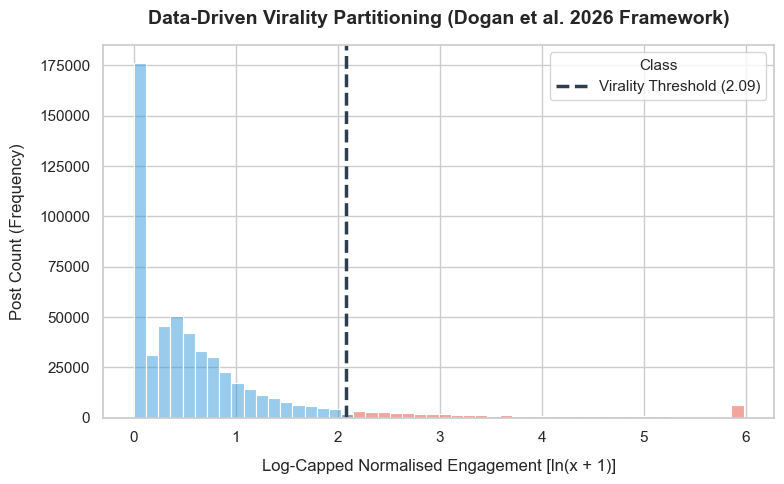

In [17]:
train_df, calculated_threshold = calculate_engagement_threshold_k_means(train_df, percentile_cap=0.99, log_cap=True)

Apply threshold calculated on training set to validation and test sets. Important that threshold is not recalculated so that there is no data leakage in the pipeline. Ni info from the test set influences the definition of virality. 

In [18]:
def apply_threshold_val_test(df, train_threshold, percentile_cap=0.99, log_cap=True):
    df, evaluation_metric = calculate_engagement_metric(df, percentile_cap, log_cap)

    df['is_viral'] = (evaluation_metric >= train_threshold).astype(int)

    cols_to_drop = ['log_capped_engagement', 'capped_engagement']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

In [19]:
val_df = apply_threshold_val_test(val_df, calculated_threshold)
print(f'--- VALIDATION SET ---')
print(f'Class distribution: {val_df["is_viral"].value_counts(normalize=True).to_dict()}\n')

test_df = apply_threshold_val_test(test_df, calculated_threshold)
print(f'--- TEST SET ---')
print(f'Class distribution: {test_df["is_viral"].value_counts(normalize=True).to_dict()}')

--- VALIDATION SET ---
Class distribution: {0: 0.9163830002359206, 1: 0.08361699976407941}

--- TEST SET ---
Class distribution: {0: 0.9150019386705778, 1: 0.08499806132942228}


### 2. Feature engineering


#### 2. Misinformation Proxies & Contextual Integrity (Credibility Vector)

Because verifying the absolute factual accuracy of thousands of historical archive posts is impossible, the pipeline establishes factual integrity boundaries using structural source attributes. **Dogan et al. (2026)** demonstrated that models relying exclusively on intrinsic content features hit a strict "Content Ceiling"; to overcome this, their framework introduces "Contextual and Network signals."

* **Operational Metrics:** The source web domain is extracted and cross-referenced against open-access journalism and independent fact-checking registries (e.g., *Media Bias/Fact Check* data profiles). This yields an objective network prior: a binary `is_low_credibility_domain` flag (1 indicating a known hyper-partisan tabloid, alternative media outlet, or conspiracy site; 0 indicating verified mainstream media).

#### 3. Psycholinguistic Cues & Stylistic Sensationalism (Affective Vector)

This layer captures the stylistic and affective elements of user communication that provoke immediate dissemination before critical processing occurs (**Vosoughi et al., 2018**). It unifies basic string formatting metrics with advanced lexical profiling.

* **Linguistic Style (Adapting Barnes et al., 2020):** Continuous tracking of structural text properties that serve as signatures of clickbait: character length, word count, uppercase letter ratios (`caps_ratio`), and explicit punctuation frequency counts for exclamation marks (`!`) and question marks (`?`).
* **Affective Profiling (LIWC Framework Integration):** Following **Dogan et al. (2026)**, who incorporated pre-engagement sentiment profiles into their tabular features, text strings are parsed to extract continuous percentage scores mapping targeted emotional and cognitive traits known to accelerate political cascades: *Anger, Anxiety, Certainty,* and *Clout*.



#### 5. Cross-Vector Interaction Generation (Phase 2.5)

Finally, to explicitly isolate the cross-over effects between political ideology and truthfulness, the pipeline manually engineers cross-vector interaction terms before training. While tree-based algorithms like **XGBoost** can natively map non-linear feature pathways (**Dogan et al., 2026**), explicitly structuring these variables provides a baseline feature space.

* **Operational Metrics:** Continuous political scores are cross-multiplied with misinformation flags and emotional metrics to generate explicit interaction columns (e.g., `political_right_score` $\times$ `is_low_credibility_domain` and `political_left_score` $\times$ `liwc_anger`). This allows the subsequent **SHAP (Shapley Additive Explanations)** interpretation suite to precisely measure the directional force multipliers of asymmetric partisanship on structural virality.

#### 2.1 Structural Metadata

**Temporal metadata**

Controls for time-based cycles Reddit platform traffic and user engagement


Following methodology of Dank or Not (Barnes et al.). Timestamp for when post first appeared on Reddit is in the Coordinated Universal Time zone (UTC). For Fakeddit, assume majority of posts created in US, so convert to North American Central Time zone, as they do in paper. For UK subreddits, convert to GMT. 

Then extract
- Time of day (in 4 hour bins)
- Day of week 
- Is weekend flag

In [20]:
def add_timezone_features(utc_val, country):
    if country == 'US': 
        timezone = 'America/Chicago'
    if country == 'UK':
        timezone = 'Europe/London'

    dt = datetime.fromtimestamp(utc_val, tz=ZoneInfo('UTC'))
    local_dt = dt.astimezone(tz=ZoneInfo(timezone))


    day_of_week = local_dt.weekday()
    is_weekend = local_dt.weekday in (5,6)
    hour_bin = local_dt.hour // 4

    bin_labels = {
    0: '12 am-4 am',
    1: '4 am-8 am',
    2: '8 am-12 pm',
    3: '12 pm-4 pm',
    4: '4 pm-8 pm',
    5: '8 pm-12 am'
    }

    time_of_day = bin_labels.get(hour_bin)

    return pd.Series([day_of_week, is_weekend, time_of_day])

In [21]:
train_df[['day_of_week', 'is_weekend', 'time_of_day']] = train_df['created_utc'].apply(add_timezone_features, args=('US',))

train_df.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,...,upvote_ratio,2_way_label,3_way_label,6_way_label,raw_engagement,normalised_engagement,is_viral,day_of_week,is_weekend,time_of_day
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,...,0.84,1,0,0,14.0,0.700000,0,6,False,12 pm-4 pm
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,...,0.99,0,2,2,121.0,12.100000,1,6,False,8 pm-12 am
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,...,0.92,1,0,0,45.0,1.836735,0,5,False,12 pm-4 pm
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,...,0.95,1,0,0,276.0,18.400000,1,1,False,4 am-8 am
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,...,0.84,0,2,2,15.0,1.500000,0,2,False,8 pm-12 am


Text(0.5, 0, 'Normalised Engagement Score')

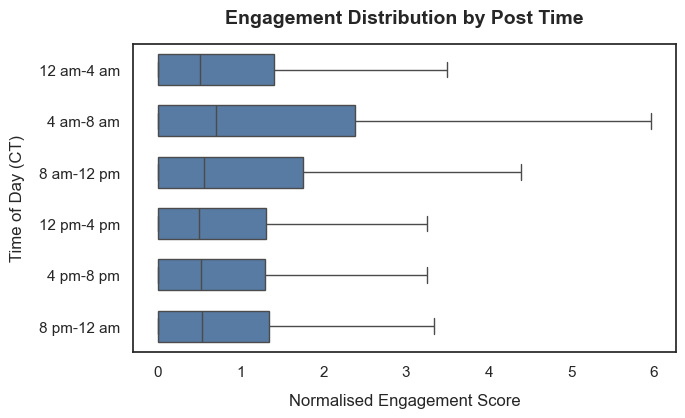

In [22]:
bin_labels = {
    0: '12 am-4 am',
    1: '4 am-8 am',
    2: '8 am-12 pm',
    3: '12 pm-4 pm',
    4: '4 pm-8 pm',
    5: '8 pm-12 am'
}

bin_order = ['12 am-4 am', '4 am-8 am', '8 am-12 pm', '12 pm-4 pm', '4 pm-8 pm','8 pm-12 am']

sns.set_theme(style='white')
plt.figure(figsize=(7,4))

ax = sns.boxplot(
    data=train_df,
    x='normalised_engagement',
    y='time_of_day',
    color='#4A7BB0',
    width=0.6,
    showfliers=False,
    order=bin_order
)

plt.title('Engagement Distribution by Post Time', fontsize=14, pad=15, fontweight='bold')
plt.ylabel('Time of Day (CT)', fontsize=12, labelpad=10)
plt.xlabel('Normalised Engagement Score', fontsize=12, labelpad=10)



**HasImage (Adapting Barnes et al., 2020):** Incorporate `hasImage` binary flag - native to Fakeddit but not to pushift dumps used for UK. Can engineer for UK - mark post as HasImage = 1 if url col includes an image extension (.jpg, .jpeg, .png, .gif) or if post_hint = image. Otherwise 0


**Word count**

Number of words in Fakeddit `clean title` column


In [23]:
def get_title_word_count(df, column):
    df['title_word_count'] = df.loc[:, column].str.split().str.len()

    return df

train_df = get_title_word_count(train_df, 'clean_title')
train_df.head()


,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,...,2_way_label,3_way_label,6_way_label,raw_engagement,normalised_engagement,is_viral,day_of_week,is_weekend,time_of_day,title_word_count
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,...,1,0,0,14.0,0.700000,0,6,False,12 pm-4 pm,15
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,...,0,2,2,121.0,12.100000,1,6,False,8 pm-12 am,7
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,...,1,0,0,45.0,1.836735,0,5,False,12 pm-4 pm,8
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,...,1,0,0,276.0,18.400000,1,1,False,4 am-8 am,5
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,...,0,2,2,15.0,1.500000,0,2,False,8 pm-12 am,9


**Processed text**

As in Dank or Not paper, all text associated with the post (for Fakeddit this is just `cleaned text`) undergoes tokenisation, lemmatisation, and stemming. Paper uses NTLK and emsim - references Rehurek and Sojka 2011; Loper and Bird 2002

In [24]:
def clean_and_stem_text(text):
    if not isinstance(text, str):
        return []
    
    # lowercase and remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    # tokenise and remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in text.split() if word not in stop_words]
    # stemming (same as Barnes et al.)
    stemmer = PorterStemmer()
    return [stemmer.stem(token) for token in tokens]

In [25]:
train_df['processed_words'] = train_df['clean_title'].apply(clean_and_stem_text)

**Domain Credibility**

Cross check domains against verfied lost of websites and heir credibility ratings. Use MBFC (Media Bias Fact Check - https://mediabiasfactcheck.com/) official ratings for `bias` and `factual reporting`. CSV is from Idiap Research Institute's github - from paper **Mapping the Media Landscape: Predicting Factual Reporting and Political Bias Through Web Interactions**

In [26]:
# load MBFC dataset
idiamap_mbfc_url = 'https://raw.githubusercontent.com/idiap/Factual-Reporting-and-Political-Bias-Web-Interactions/main/data/mbfc.csv'
mbfc_df = pd.read_csv(idiamap_mbfc_url)
mbfc_df.head()


,source,bias,factual_reporting
0,9news.com,neutral,high
1,nbc11news.com,neutral,high
2,12news.com,neutral,high
3,wibw.com,neutral,high
4,wifr.com,neutral,high


In [27]:
# check uk domains present 
uk_targets = ['theguardian.com', 'independent.co.uk', 'gbnews.uk', 'bbc.co.uk', 'dailymail.co.uk']
uk_check = mbfc_df[mbfc_df['source'].isin(uk_targets)]
print(uk_check)

# check major us domains present
us_targets = ['nytimes.com', 'foxnews.com', 'breitbart.com', 'washingtonpost.com', 'thegatewaypundit.com']
us_check = mbfc_df[mbfc_df['source'].isin(us_targets)]
print(us_check)

                 source         bias factual_reporting
1704    theguardian.com  left-center             mixed
1708  independent.co.uk  left-center             mixed
1722    theguardian.com  left-center             mixed
2764    dailymail.co.uk        right               low
2868          gbnews.uk        right             mixed
                    source         bias factual_reporting
1600           nytimes.com  left-center              high
1806    washingtonpost.com  left-center             mixed
2681         breitbart.com        right             mixed
2854           foxnews.com        right             mixed
3370  thegatewaypundit.com        right               low


In [28]:
# add domain bias and factuality cols to main df

mbfc_df['source_clean'] = mbfc_df['source'].str.lower().str.strip().str.replace('www.', '', regex=False)

# create lookup maps using cleaned source column
bias_map = dict(zip(mbfc_df['source_clean'], mbfc_df['bias']))
factuality_map = dict(zip(mbfc_df['source_clean'], mbfc_df['factual_reporting']))


train_df['domain_clean'] = train_df['domain'].str.lower().str.strip().str.replace('www.', '', regex=False)

# create new cols using cleaned domain column
train_df['mbfc_bias'] = train_df['domain_clean'].map(bias_map).fillna('unknown_unrated')
train_df['mbfc_factuality'] = train_df['domain_clean'].map(factuality_map).fillna('unknown_unrated')

# handle native reddit self posts (no external domain)
is_self_post = train_df['domain_clean'].str.contains('self\.', na=False) | train_df['domain_clean'].isin(['reddit.com', 'v.redd.it', 'i.redd.it'])
train_df.loc[is_self_post, ['mbfc_bias', 'mbfc_factuality']] = 'native_reddit'


train_df.drop(columns=['domain_clean'], inplace=True)

<>:17: SyntaxWarning: invalid escape sequence '\.'
<>:17: SyntaxWarning: invalid escape sequence '\.'
/var/folders/t4/0d1lqpmd2tbgrjws_z5wznt40000gn/T/ipykernel_84350/2595997183.py:17: SyntaxWarning: invalid escape sequence '\.'
  is_self_post = train_df['domain_clean'].str.contains('self\.', na=False) | train_df['domain_clean'].isin(['reddit.com', 'v.redd.it', 'i.redd.it'])


#### 2.2 Psycholinguistic features

**Research question:** do misinformation posts go viral for different emotional reasons than factual posts? → requires emotional granularity, not just polarity

**Why not Barnes et al. approach?**
- Barnes et al. (2020) use Liu & Zhang (2012) opinion lexicon → coarse positive/negative/neutral only
- Cannot distinguish anger vs fear vs disgust → SHAP analysis would be uninterpretable

**Framework: Zhang et al. (2021, WWW) — "Mining Dual Emotion for Fake News Detection"**
- Most cited recent framework for emotion + fake news
- Publisher emotion (post text) + social emotion (comments) → dual emotion
- Social emotion and emotion gap shown to matter more than publisher emotion alone
- **Implementing publisher emotion component only** — Fakeddit has comment counts but not comment text, so social emotion is unavailable. Noted as a limitation.
- Publisher emotion features in Zhang et al.: emotion category, emotional lexicon, emotional intensity, sentiment score, auxiliary (punctuation/caps)
- Implementing **emotional lexicon** (EmoLex) + **sentiment score** (VADER) components — sufficient for tabular XGBoost feature matrix without additional classifiers

**Tool 1 — NRC Word-Emotion Association Lexicon (EmoLex; Mohammad & Turney, 2013)**
- 8 discrete emotions: anger, fear, joy, trust, disgust, sadness, anticipation, surprise
- Returns proportion of matched words per emotion (`affect_frequencies`) — already normalised by word count
- Granularity enables SHAP to distinguish which specific emotions drive viral misinfo vs viral truth
- Used in Giachanou et al. (2019, SIGIR) for credibility detection — directly justifies lexicon choice
- Vosoughi et al. (2018): false news triggers fear, disgust, surprise; true news triggers joy, trust, anticipation → theoretical motivation for these specific dimensions

**Tool 2 — VADER compound sentiment score (Hutto & Gilbert, 2014)**
- Single compound score [-1, 1]
- Designed for social media text — handles capitalisation, punctuation, slang
- Complements EmoLex: captures aggregate valence where EmoLex has no lexicon match (e.g. political proper nouns "Starmer", "NHS", "Brexit" return zero NRC scores but VADER scores surrounding language)
- Implements Zhang et al.'s sentiment score component

**Citation roles**
- Zhang et al. (2021, WWW) — framework being implemented (publisher emotion, emotional lexicon + sentiment score)
- Giachanou et al. (2019, SIGIR) — theoretical justification that granular emotion categories outperform sentiment polarity for credibility detection; uses EmoLex directly
- Mohammad & Turney (2013) — NRC EmoLex tool citation
- Hutto & Gilbert (2014) — VADER tool citation
- Vosoughi et al. (2018, Science) — theoretical motivation: false news is more emotionally charged and propagates differently from true news across all valence dimensions

**Note on Giachanou et al. citation:** their implementation is architectural (LSTM), not tabular — cite for theoretical motivation and lexicon justification only, not for the specific feature engineering approach

In [49]:
vader = SentimentIntensityAnalyzer()

# 8 emotions from EmoLex
nrc_emotions = ['anger', 'fear', 'joy', 'trust', 'disgust', 'sadness', 'anticipation', 'surprise']

_nrc = NRCLex()

def extract_emotion_features(text):
    """
    Extract NRC Emolex emotion proportions (col 0-1 for each emotion) and VADER compound sentiment (-1 to 1)

    """

    # account for empty/null input
    if not isinstance(text, str) or not text.strip():
        return {f'emo_{e}': 0.0 for e in nrc_emotions} | {'vader_component': 00}


    _nrc.load_raw_text(text)
    freq = _nrc.affect_frequencies # proportion 0-1 for each emotion 


    vs = vader.polarity_scores(text)

    return (
        {f'emo_{e}': freq.get(e, 0) for e in nrc_emotions} | 
        {'vader_compound': vs['compound']}
    )

In [50]:
# Check to see if outputs look sensible before full run 

spot_check_texts = [
    "Starmer slammed for betraying working class voters",
    "Government announces record NHS funding boost",
    "Rioters attack mosque in shocking scenes of violence",
    "Study finds immigrants commit more crime says report",
    "Local charity raises money for flood victims",
    "",    # empty — should return all zeros
    None,  # null — should return all zeros
]
 
print("=== Spot-check: emotion features on sample titles ===\n")
for text in spot_check_texts:
    feats = extract_emotion_features(text)
    nonzero = {k: round(v, 3) for k, v in feats.items() if v != 0.0}
    print(f"  Text: {repr(str(text)[:60])}")
    print(f"  Non-zero features: {nonzero}\n")

=== Spot-check: emotion features on sample titles ===

  Text: 'Starmer slammed for betraying working class voters'
  Non-zero features: {'vader_compound': -0.542}

  Text: 'Government announces record NHS funding boost'
  Non-zero features: {'vader_compound': 0.402}

  Text: 'Rioters attack mosque in shocking scenes of violence'
  Non-zero features: {'emo_anger': 0.375, 'emo_fear': 0.25, 'emo_sadness': 0.125, 'vader_compound': -0.872}

  Text: 'Study finds immigrants commit more crime says report'
  Non-zero features: {'emo_anger': 0.333, 'emo_fear': 0.333, 'vader_compound': -0.38}

  Text: 'Local charity raises money for flood victims'
  Non-zero features: {'emo_anger': 0.154, 'emo_fear': 0.154, 'emo_joy': 0.154, 'emo_trust': 0.077, 'emo_sadness': 0.077, 'emo_anticipation': 0.077, 'emo_surprise': 0.077, 'vader_compound': 0.128}

  Text: ''
  Non-zero features: {}

  Text: 'None'
  Non-zero features: {}



Demonstrates limitiation of EmoLex - operates at word level, doesn't use overall context of text. Local charity raises money for flood victims is positive but 'flood' and 'victims' result in fear and anger scores.

Scores won't necessarily sum to 1 - `affect_frequencies` normalises by total word count in text, so if only 6 out of 9 words in the title match an emotion in the lexicon, the resulting emotion proportions will only add to 0.66

In [53]:
text_col = 'clean_title'

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'Processing {name}: {len(df)} rows')
    start = time.time()

    emo_features = pd.DataFrame(
        df[text_col].apply(extract_emotion_features).tolist(),
        index=df.index
    )

    # join emo features back to original df
    for col in emo_features.columns:
        df[col] = emo_features[col]
    
    end = time.time()
    elapsed = end - start
    print(f'Finished in {elapsed:2f}s')

emo_cols = [f'emo_{e}' for e in nrc_emotions] + ['vader_compound']
print(f"\nNew columns: {emo_cols}")
print(f"\nTrain set — mean emotion scores:")
print(train_df[emo_cols].mean().round(4).to_string())
print(f"\nNull counts: {train_df[emo_cols].isnull().sum().sum()} (should be 0)")

Processing train: 564000 rows
Finished in 75.640388s
Processing val: 59342 rows
Finished in 8.838211s
Processing test: 59319 rows
Finished in 13.125759s

New columns: ['emo_anger', 'emo_fear', 'emo_joy', 'emo_trust', 'emo_disgust', 'emo_sadness', 'emo_anticipation', 'emo_surprise', 'vader_compound']

Train set — mean emotion scores:
emo_anger           0.0366
emo_fear            0.0563
emo_joy             0.0477
emo_trust           0.0808
emo_disgust         0.0266
emo_sadness         0.0325
emo_anticipation    0.0601
emo_surprise        0.0303
vader_compound      0.0104

Null counts: 0 (should be 0)


In [ ]:
# Quick sanity check: do misinformation posts have higher anger/fear
# than authentic posts? This is the theoretical prediction.
# If not, worth investigating before training XGBoost.
 
print("\n=== Mean emotion scores by 3-way veracity label ===")
print("({0: 'True', 1: 'Fake (true text / propaganda)', 2: 'Fake (false text / manipulated)'"04_BERT_classifier.ipynb)
print(
    train_df.groupby('3_way_label')[emo_cols]
    .mean()
    .round(4)
    .to_string()
)


=== Mean emotion scores by 3-way veracity label ===
(0=Authentic, 1=Fake, 2=Satire)

             emo_anger  emo_fear  emo_joy  emo_trust  emo_disgust  emo_sadness  emo_anticipation  emo_surprise  vader_compound
3_way_label                                                                                                                   
0               0.0403    0.0646   0.0579     0.1027       0.0300       0.0373            0.0651        0.0347          0.0136
1               0.0521    0.1018   0.0475     0.1022       0.0246       0.0417            0.0727        0.0242         -0.0115
2               0.0334    0.0489   0.0408     0.0650       0.0244       0.0289            0.0562        0.0276          0.0092


**Emotion distribution by veracity class (train set)**
Labels: 0 = True (222k), 1 = Fake/true text — propaganda only (14k), 2 = Fake/false text — image manipulation + satire (328k)
Primary comparison for downstream analysis: **label 0 vs label 2**

- Label 2 scores *lower* than label 0 on nearly all emotion dimensions — counterintuitive given misinformation literature
- `emo_fear`: label 0 (0.065) > label 2 (0.049) — true content more fear-laden than fake/false text
- `emo_trust`: label 0 (0.103) > label 2 (0.065) — true content scores substantially higher
- `emo_joy`: label 0 (0.058) > label 2 (0.041) — same direction
- `vader_compound`: label 0 (+0.014) > label 2 (+0.009) — both mildly positive, minimal difference
- **Explanation:** label 2 is dominated by image-manipulation subreddits (`psbattle_artwork` 168k, `pareidolia` 47k, `fakehistoryporn` 36k) — titles are mostly descriptive captions ("PsBattle: puppy taking in the view") with minimal emotional content; emotion signal is suppressed by design of those subreddits
- Label 1 (`propagandaposters` only, 14k) is the genuinely emotionally distinctive class — highest fear (0.102), anger, and negative VADER (-0.012) — but not a generalisable finding given it is a single subreddit
- **Key methodological implication:** emotion features are unlikely to be strong discriminators between label 0 and label 2 in the XGBoost model — this is a direct consequence of using a text-only approach on a multimodal dataset where label 2 fakeness is primarily visual, not linguistic
- Mann-Whitney U on label 0 vs 2: run and record effect sizes (rank-biserial r) alongside p-values — large n means near-certain significance, effect size is what matters

In [59]:
from scipy.stats import mannwhitneyu

authentic = train_df[train_df['3_way_label'] == 0]
fake      = train_df[train_df['3_way_label'] == 2]

print(f"Comparing label 0 (True, n={len(authentic):,}) vs label 2 (Fake/false text, n={len(fake):,})\n")

for col in ['emo_fear', 'emo_anger', 'emo_joy', 'emo_trust', 'vader_compound']:
    stat, p = mannwhitneyu(
        fake[col], authentic[col], alternative='two-sided'
    )
    # effect size: rank-biserial correlation r = 1 - (2U)/(n1*n2)
    n1, n2 = len(fake), len(authentic)
    r = 1 - (2 * stat) / (n1 * n2)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{col:20s}  p={p:.4f}  r={r:.3f}  {sig}")

Comparing label 0 (True, n=222,081) vs label 2 (Fake/false text, n=328,071)

emo_fear              p=0.0000  r=0.072  ***
emo_anger             p=0.0000  r=0.052  ***
emo_joy               p=0.0000  r=0.086  ***
emo_trust             p=0.0000  r=0.134  ***
vader_compound        p=0.0000  r=0.012  ***


**Mann-Whitney U results: label 0 (True) vs label 2 (Fake/false text)**

All comparisons p<0.001 (***) — expected given n=222k vs 328k; effect sizes are what matter.

| Feature | r | Interpretation |
|---|---|---|
| `emo_trust` | 0.134 | Largest effect — true content uses more trust-associated language |
| `emo_joy` | 0.086 | True content more joyful |
| `emo_fear` | 0.072 | True content more fear-laden (driven by news content) |
| `emo_anger` | 0.052 | True content marginally more angry |
| `vader_compound` | 0.012 | Negligible — both classes near-neutral, VADER adds no discriminative signal between 0 and 2 |

Effect size conventions (rank-biserial r): small ≈ 0.1, medium ≈ 0.3, large ≈ 0.5

- All effects are **small** (r < 0.15) — statistically significant but modest practical difference
- Direction is consistently **label 0 > label 2** — true content is more emotionally loaded, not fake content
- Confirms the structural explanation: label 2 titles are descriptive captions from image subreddits, suppressing all emotion signals
- `vader_compound` (r=0.012) effectively useless as a discriminator between these classes — may still contribute to virality prediction but not veracity separation
- `emo_trust` (r=0.134) is the strongest signal — worth monitoring in SHAP output
- These results reinforce the methodological caveat: emotion features will not be strong Pipeline B discriminators for veracity; their value lies in the **virality** prediction and **intersection analysis**, not classification of fake vs true

In [61]:
train_df.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,...,mbfc_factuality,emo_anger,emo_fear,emo_joy,emo_trust,emo_disgust,emo_sadness,emo_anticipation,emo_surprise,vader_compound
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,...,unknown_unrated,0.0,0.0,0.000000,0.000000,0.0,0.000000,1.000000,0.0,0.00
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,...,native_reddit,0.0,0.5,0.000000,0.000000,0.0,0.500000,0.000000,0.0,0.00
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,...,mixed,0.0,0.0,0.000000,0.333333,0.0,0.000000,0.000000,0.0,-0.34
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,...,unknown_unrated,0.0,0.0,0.000000,0.333333,0.0,0.000000,0.333333,0.0,0.00
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,...,native_reddit,0.0,0.0,0.333333,0.166667,0.0,0.166667,0.000000,0.0,0.00


## Checkpoint: emotion features — what the results mean and how to proceed

**What we found**
- Mann-Whitney U, label 0 (True) vs label 2 (Fake/false text): all p<0.001 but all effect sizes small (r=0.012–0.134)
- Direction is consistently label 0 > label 2 — true content scores *higher* on fear, trust, joy, anger than fake content
- Opposite to theoretical predictions from Vosoughi et al. (2018) and Giachanou et al. (2019)
- VADER compound near-identical between classes (r=0.012) — negligible discriminative signal

**Why this is a Fakeddit artefact, not a theoretical failure**
- Label 2 (328k posts) is 85% image-manipulation subreddits: `psbattle_artwork` (168k), `pareidolia` (47k), `fakehistoryporn` (36k)
- These subreddits produce descriptive captions ("PsBattle: puppy taking in the view") — minimal emotional language by design
- The emotion literature's predictions apply to *political and news misinformation*, not photoshop competitions
- Label 0 (True) contains `neutralnews`, `usnews`, `upliftingnews` — news and uplifting content that genuinely uses emotional language
- This is a dataset composition problem, not a failure of emotion features as a concept

**Does this derail the Phase 2 UK transfer?**
- No — UK corpus (r/ukpolitics, r/LabourUK, r/tories etc.) is exclusively text-driven political content with no image-manipulation equivalent
- Emotion signal in UK political Reddit titles expected to be substantially stronger and more discriminative
- Fakeddit result becomes a *baseline comparison* — "emotion features were weak on the multimodal Fakeddit corpus but stronger on the text-only UK corpus" is itself a finding
- Phase 2 is where the genuine emotion-misinformation relationship will be tested

**The XGBoost contamination risk**
- Real concern: XGBoost will learn inverted emotional signals from Fakeddit training data (higher fear/trust = more likely True, not Fake)
- Mitigation 1: Pipeline B predicts **virality**, not veracity — emotion features are learning "does anger drive viral sharing?" not "does anger indicate fakeness?". This relationship is less contaminated by label composition.
- Mitigation 2: veracity signal in Pipeline B comes from `p_fake` (BERT softmax probability) — emotion features characterise posting *style*, `p_fake` carries the veracity signal. They are asking different questions in the feature matrix.
- Residual risk: if XGBoost uses emotion features as a proxy for veracity within the virality task, the learned direction will be inverted relative to real-world political misinformation. This is a legitimate limitation.
- Must be stated explicitly in limitations section

**How to proceed**
- Keep all 9 emotion features (8 NRC + VADER) in the feature matrix — their weakness on Fakeddit is now documented and explained
- In Phase 1, treat emotion features as **virality predictors** (emotional framing drives sharing) rather than veracity proxies
- Monitor SHAP output: if `emo_fear` and `emo_anger` have high SHAP values for virality but the direction is counterintuitive, flag it explicitly
- In Phase 2 UK analysis, re-examine emotion distributions by credibility label — expect a stronger and correctly-directed signal on political text
- Add to limitations: *"Emotion features showed inverted signals relative to theoretical predictions on Fakeddit, attributable to label 2's image-manipulation composition. The learned emotional associations may not transfer cleanly to real-world political misinformation contexts. Phase 2 on UK political Reddit represents a more appropriate test of the emotion-misinformation hypothesis."*

### 2.3. Directional Political Leaning (Ideological Vector)

Relevant papers: 
**"Large Language Models Unpack Complex Political Opinions through Target-Stance Extraction" (Togay et al., 2026)**

* Validates ability of instruction-tuned LLMs to extract nuanced political stances from **Reddit posts** without extensive domain fine-tuning.
* Justifies choice to use zero-shot classification structures (`bart-large-mnli`) to automate the dissection of complex political commentary on social media.

**"Automated Media Assessment Using Large Language Models" (2024/2025)**

* Establishes a standard framework for utilising zero-shot prompting systems to extract latent, qualitative elements (such as textual stance, perspective, and framing) out of text data structures.
* Justifies extracting tabular features from text. Demonstrates that converting qualitative bias dimensions into structured quantitative variables enhances downstream classification tasks.

**"Early Multimodal Prediction of Post Popularity on Social Media" (Dogan et al., 2026)**

* Advances social media virality forecasting by incorporating zero-shot trait annotations derived via deep transformer models alongside standard tabular metadata.
* This serves as the core architectural anchor for your machine learning layout, justifying the shift away from old bag-of-words keyword counting matrices to continuous semantic distributions fed into an ensemble classifier like XGBoost.

**Lewis et al. (2020) created the BART model architecture.**

**Benchmarking Zero-shot Text Classification: Datasets, Evaluation and Entailment Approach (Yin et al., 2019)**
the zero-shot text classification framework I'm using.  Classification reframed as a structural Natural Language Inference (NLI) problem: the post text  evaluated against custom, target candidate hypotheses.


e.g. 
"To capture continuous political leaning, the pipeline moves away from classic keyword-counting methods. Following the framework of Dogan et al. (2026), text features are transformed into zero-shot trait annotations to assist in popularity forecasting. This application builds on Togay et al. (2026), who validated that zero-shot transformer models can successfully extract nuanced political stances directly from Reddit text. Specifically, this study implements the facebook/bart-large-mnli model, utilizing the sequence-to-sequence architecture developed by Lewis et al. (2020) and the zero-shot inference method established by Yin et al. (2019) to output three continuous probability fields: left-wing, right-wing, and neutral scores."

Adapting methodology of **Dogan et al. (2026)** - uses LLMs and a zero-shot method to extract semantic features:
- Pass textual cols through a pre-trained natural language inference transformer (`bart-large-mnli`).
- Model outputs three continuous, zero-sum probability fields: `political_left_score`, `political_right_score`, and `political_neutral_score`. Continuous spectrum of political leaning 
- Using **zero-shot classification** - model predicts class that wasn't seen during training 

Why `facebook/bart-large-mnli`?
- Uses natural language inference (NLI) frameowrk - model calculates proability that piece of text fits a given category. Use `multi_label=False` to restrict multiple classifications. Result is normlised numberical political leaning features that can be used for downstream ensemble learning. 

In [16]:
def extract_political_leaning(df, text_column, batch_size=32):
    """
    Extracts numerical political leaning scores using facebook/bart-large-mnli
    Returns original df with 3 additional columns
    """
    torch.cuda.empty_cache()
    
    # Check GPU available 
    device = 0 if torch.cuda.is_available() else -1

    # float16 to cut memory usage
    model_kwargs = {"torch_dtype": torch.float16} if device == 0 else {}

    # Load zero-shot classifier
    classifier = pipeline(
        'zero-shot-classification',
        model='facebook/bart-large-mnli',
        device=device,
        model_kwargs=model_kwargs
    )

    candidate_labels = ['left-wing political bias', 'right-wing political bias', 'politically neutral']

    # convert texts into a hugging face dataset
    cleaned_series = df[text_column].fillna("").astype(str)
    hf_dataset = Dataset.from_dict({"text": cleaned_series})

    left_scores = []
    right_scores = []
    neutral_scores = []

    print(f'Processing {len(df)} rows')

    with torch.no_grad():
        outputs = classifier(KeyDataset(hf_dataset, 'text'), candidate_labels=candidate_labels, multi_label=False)

        # Process text in mini batches to speed up process
        for output in tqdm(outputs, total=len(df)):
            score_dict = dict(zip(output['labels'], output['scores']))
            left_scores.append(score_dict['left-wing political bias'])
            right_scores.append(score_dict['right-wing political bias'])
            neutral_scores.append(score_dict['politically neutral'])
    
    df['political_left_score'] = left_scores
    df['political_right_score'] = right_scores
    df['political_neutral_score'] = neutral_scores

    df_out = df.copy()
    
    return df_out


In [ ]:
fakeddit_train_df_features = extract_political_leaning(train_df, 'clean_title', batch_size=32)

fakeddit_train_df_features.to_csv("../data/processed/US/fakeddit_train_with_political_features.csv", index=False)


Loading weights: 100%|██████████| 515/515 [00:00<00:00, 518.44it/s] 


Processing 564000 rows


  0%|          | 243/564000 [00:15<9:22:19, 16.71it/s]

### 3. Model Architecture & Training 

Framework: An optimized XGBoost Classifier cross-validated against a baseline Random Forest Classifier (Barnes et al., 2020; Dogan et al., 2026).

Metrics: Model optimization targets PR-AUC and Macro-F1 to correctly evaluate performance against the intentional 80/20 target class skew (Dogan et al., 2026).

Explainability: Post-hoc extraction of global and localized SHAP values, contrasting the feature profiles of authentic viral posts versus misinformation viral posts to map algorithmic bias (Lundberg & Lee, 2017; Hashmi et al., 2024).



### 4. Model Evaluation 

Because virality classification features an inherent class imbalance, raw "Accuracy" is a misleading metric (a dummy model guessing 0 every time would achieve ~91.5% accuracy). Your evaluation framework will instead prioritize:

ROC-AUC (Receiver Operating Characteristic - Area Under Curve): Measures the model's overall capability to cleanly separate viral content from non-viral content across all potential probability thresholds.

Precision-Recall AUC (PR-AUC): The definitive evaluation metric for imbalanced datasets, focusing exclusively on the model's performance regarding the minority Viral (1) class.

Confusion Matrix Breakdown: Analysis of precise operational performance at the optimal decision boundary:

Precision: Out of all posts the model predicted would go viral, how many actually did? (Minimizes false alarms).

Recall (Sensitivity): Out of all posts that actually went viral, how many did the model successfully catch? (Minimizes missed opportunities).



### 5. Feature importance and interpretability

SHAP (SHapley Additive exPlanations): Deploy SHAP values across your trained XGBoost model. This leverages cooperative game theory to measure the exact directional contribution of every feature toward a post's final virality score.

The Cross-Layer Analysis: You will generate SHAP summary plots to explicitly answer your core research questions:

Do high emotional LIWC metrics (e.g., anger, anxiety) increase the probability of virality more than neutral semantic BERT embeddings?

Does alignment with specific UK political figures or controversial policies act as an accelerator for content traction?
